In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../apps/api"))

import json
import logging
import boto3
import pandas as pd
import matplotlib.pyplot as plt

from livewell.backtest.loader import load_all_signals, load_price_history
from livewell.backtest.outcome import resolve_trade
from livewell.backtest.aggregator import build_summary

logging.basicConfig(level=logging.WARNING)

BUCKET = "livewell-data-prod"
ENV = "prod"

print("Setup complete.")

Setup complete.


In [2]:
signals = load_all_signals(env=ENV)
print(f"Loaded {len(signals)} signals with direction != 'none'")
instruments = list({s["s3_key"] for s in signals})
print(f"Instruments: {sorted(instruments)}")

Loaded 15048 signals with direction != 'none'
Instruments: ['AUDJPY', 'AUDUSD', 'CL', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPJPY', 'GBPUSD', 'NG', 'NKD', 'NQ', 'RTY', 'US500', 'USDCAD', 'USDCHF', 'USDJPY', 'USDMXN', 'XAUUSD', 'YM']


In [3]:
trades = []
skipped = 0

for s3_key in sorted(instruments):
    price_df = load_price_history(s3_key, BUCKET)
    if price_df.empty:
        print(f"WARNING: no price history for {s3_key}, skipping")
        continue
    instrument_signals = [s for s in signals if s["s3_key"] == s3_key]
    for signal in instrument_signals:
        result = resolve_trade(signal, price_df)
        if result is None:
            skipped += 1
        else:
            trades.append(result)

print(f"Resolved {len(trades)} trades, skipped {skipped}")

Resolved 15048 trades, skipped 0


In [4]:
summary = build_summary(trades)
print(f"Total trades: {summary['totalTrades']}")
print(f"Win rate:     {summary['winRate']:.1%}")
print(f"Avg edge:     {summary['avgEdge']:.1%}")
print(f"Max drawdown: {summary['maxDrawdown']:.1%}")
print()
print("signal_valid split:")
split = summary["signalValidSplit"]
print(f"  Valid signals:   {split['valid']['trades']} trades, {split['valid']['winRate']:.1%} win rate")
print(f"  Invalid signals: {split['invalid']['trades']} trades, {split['invalid']['winRate']:.1%} win rate")

Total trades: 15048
Win rate:     18.8%
Avg edge:     -52.9%
Max drawdown: -31852.0%

signal_valid split:
  Valid signals:   3998 trades, 17.9% win rate
  Invalid signals: 11050 trades, 19.2% win rate


In [5]:
rows_df = pd.DataFrame(summary["rows"])
if not rows_df.empty:
    pivot = rows_df.groupby("market")[["winRate", "trades"]].apply(
        lambda g: pd.Series({
            "winRate": (g["winRate"] * g["trades"]).sum() / g["trades"].sum(),
            "trades": g["trades"].sum()
        })
    ).sort_values("winRate", ascending=False)
    print(pivot.to_string())

         winRate  trades
market                  
XAUUSD  0.274970   720.0
NG      0.227051   762.0
NKD     0.216112   796.0
US500   0.208380   816.0
NQ      0.206986   826.0
RTY     0.202308   786.0
CL      0.197883   753.0
USDCHF  0.193333   750.0
GBPUSD  0.191711   772.0
AUDJPY  0.190517   803.0
USDJPY  0.180255   771.0
YM      0.179232   837.0
AUDUSD  0.175582   803.0
EURUSD  0.172481   806.0
USDCAD  0.169188   792.0
EURJPY  0.166045   825.0
USDMXN  0.161966   809.0
GBPJPY  0.140724   803.0
EURGBP  0.136884   818.0


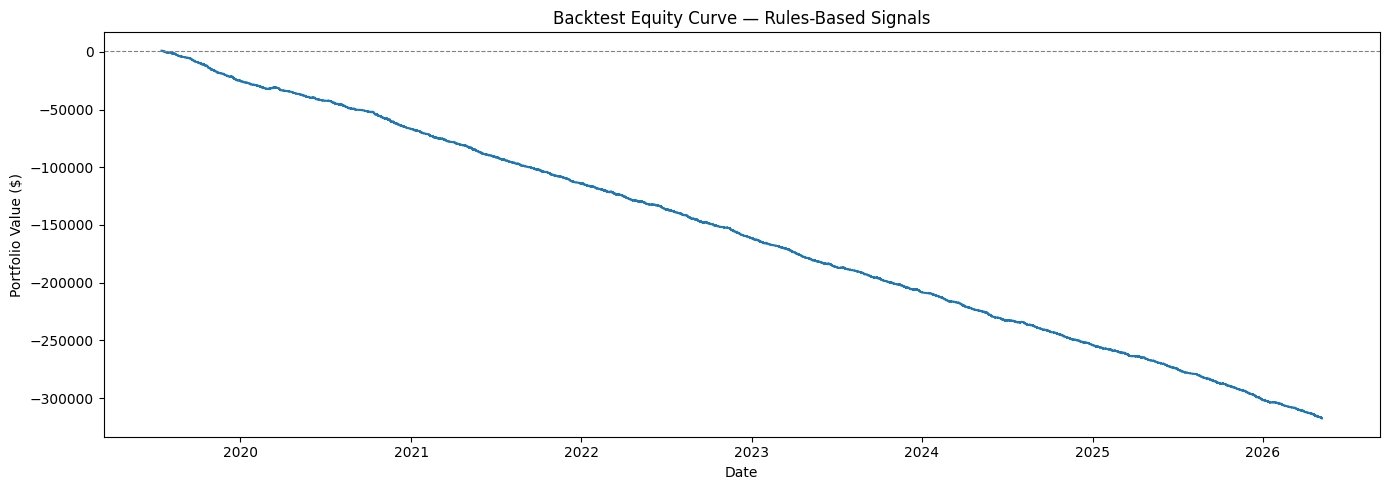

In [6]:
curve_df = pd.DataFrame(summary["equityCurve"])
if not curve_df.empty:
    curve_df["date"] = pd.to_datetime(curve_df["date"])
    plt.figure(figsize=(14, 5))
    plt.plot(curve_df["date"], curve_df["value"])
    plt.axhline(1000, color="gray", linestyle="--", linewidth=0.8)
    plt.title("Backtest Equity Curve — Rules-Based Signals")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.tight_layout()
    plt.show()

In [7]:
# Trim equityCurve to monthly points to keep JSON small
curve_df = pd.DataFrame(summary["equityCurve"])
if not curve_df.empty:
    curve_df["date"] = pd.to_datetime(curve_df["date"])
    curve_df = curve_df.set_index("date").resample("ME").last().reset_index()
    curve_df["date"] = curve_df["date"].dt.strftime("%Y-%m-%d")
    summary["equityCurve"] = curve_df[["date", "value"]].to_dict(orient="records")

# Add expiryWindow field to rows (required by schema)
for row in summary["rows"]:
    row["expiryWindow"] = "Daily"

s3 = boto3.client("s3")
body = json.dumps(summary, default=str).encode()
s3.put_object(Bucket=BUCKET, Key="backtest/summary.json", Body=body, ContentType="application/json")
print(f"Written {len(body)} bytes to s3://{BUCKET}/backtest/summary.json")

Written 9271 bytes to s3://livewell-data-prod/backtest/summary.json


In [8]:
import urllib.request, urllib.error
API_URL = "https://3rxkdcbg4w2yshiyzoqsnd6c6q0cjjoo.lambda-url.us-west-1.on.aws"
try:
    with urllib.request.urlopen(f"{API_URL}/api/backtest/summary") as resp:
        data = json.loads(resp.read())
    print(f"API returned {data['totalTrades']} trades, win rate {data['winRate']:.1%}")
except urllib.error.HTTPError as e:
    print(f"HTTP {e.code} — has the backtest been written to S3 yet?")
except urllib.error.URLError as e:
    print(f"Cannot reach API: {e.reason}")

API returned 15048 trades, win rate 18.8%
